In [3]:
import config as k
import ccxt
import pandas as pd
import numpy as np
import pandas_ta as ta
import decimal as dc
import matplotlib as mt
import time

binance = ccxt.binance({
    'enableRateLimit': True,
    'apiKey': k.binancekey,
    'secret': k.binacesecret,
    'options': {
        'defaultType': 'future'
    },
})

bal = binance.fetch_positions(symbols=['XRPUSDT']) #moeda entra aqui

In [11]:
#symbol = 'XRPUSDT'
#ativo_ofertas = biance.fetch_order_book(symbol)
#bid = dc.Decimal(livro_ofertas['bids'][0][0])
#ask = dc.Decimal(livro_ofertas['asks'][0][0])
#print(bid,ask) #melhor preco de compra e venda

def livro_ofertas(symbol):
    livro_ofertas = binance.fetch_order_book(symbol)
    bid = dc.Decimal(livro_ofertas['bids'][0][0])
    ask = dc.Decimal(livro_ofertas['asks'][0][0])
    return bid, ask #melhor preco de compr e venda

In [12]:
def posicoes_abertas(symbol):
    lado = []
    tamanho =[]
    preco_entrada = []
    notional =[]
    percetage = []
    pnl = []
    bal = binance.fetch_positions(symbols=[symbol]) #moeda entr aqui

    for i in bal:
        lado = i['side']
        tamanho = i['info']['positionAmt'].replace('-', '')
        preco_entrada = i['entryPrice']
        notional = i['notional']
        percetage = i['percetage']
        pnl = i['info']['umRealizeProfit']

    if lado == 'long':
            pos_aberta = True
    elif lado == 'short':
            pos_aberta = True
    else:
            pos_aberta = False
        

            return lado, tamanho, preco_entrada,pos_aberta, notional, percetage,pnl
    
pos_aberta = posicoes_abertas('XRPUSDT')[3]
print(pos_aberta)

False


In [13]:
symbol = 'XRPUSDT'

def encerra_posicao(symbol):
    pos_aberta = posicoes_abertas(symbol=symbol)[3]

    while pos_aberta == True:
        lado = posicoes_abertas(symbol=symbol)[0]
        tamanho = posicoes_abertas(symbol=symbol)[1]


        if lado == 'long':
            binance.cancel_all_orders(symbol)
            bid,ask = livro_ofertas(symbol)
            ask = binance.price_to_precision(symbol,ask)
            binance.create_order(symbol, side='sell', type='LIMIT', price=ask, amount=tamanho, params={'hedged': 'True'})
            print(f'Vendendo posição long de {tamanho} moedas de {symbol}')
            time.sleep(20)


        elif lado == 'short':
            binance.cancel_all_orders(symbol)
            bid,ask = livro_ofertas(symbol)
            bid = binance.price_to_precision(symbol,bid)
            
            binance.create_order(symbol, side='buy', type='LIMIT', price=bid, amount=tamanho, params={'hedged': 'True'})
            print(f'Comprando posição short de {tamanho} moedas de {symbol}')
            time.sleep(20)
        else:
            print('Impossivel encerrar posição')

        pos_aberta = posicoes_abertas(symbol=symbol)[3]

       


In [ ]:

loss = -10
target = 20

def fecha_pnl(symbol,loss,target):
    percent = posicoes_abertas(symbol=symbol)[5]
    pnl = posicoes_abertas(symbol=symbol)[6]
    if percent:
        if percent <=loss:
            print(f'Encerrdo posicao por loss! {pnl}')
            encerra_posicao(symbol)
            #telegram
            #time.sleep(3000)
        elif percent >= target:
            print(f'Encerrdo posicao por gain! {pnl}')
            

In [15]:
symbol = 'TrumpCoin'
timeframe = '5m'
bars = binance.fetch_ohlcv(symbol=symbol, timeframe=timeframe, limit=300)
df_candles = pd.DataFrame(bars, columns=['time', 'abertura', 'max', 'min', 'fechamento', 'volume'])
df_candles['time'] = pd.to_datetime(df_candles['time'], unit='ms', utc=True).map(lambda x: x.tz_convert('America/Sao_Paulo'))

BadSymbol: binance does not have market symbol TrumpCoin

,time,abertura,max,min,fechamento,volume
0,2025-01-22 12:45:00-03:00,104252.3,104337.2,104008.7,104309.0,640.083
1,2025-01-22 12:50:00-03:00,104309.4,104631.3,104046.0,104551.9,729.380
2,2025-01-22 12:55:00-03:00,104551.9,104581.0,104138.0,104138.0,529.916
3,2025-01-22 13:00:00-03:00,104138.1,104186.9,103711.7,103867.2,1841.244
4,2025-01-22 13:05:00-03:00,103867.2,104074.5,103724.8,103860.7,1203.636
...,...,...,...,...,...,...
295,2025-01-23 13:20:00-03:00,105774.6,105929.6,105260.3,105659.9,5593.020
296,2025-01-23 13:25:00-03:00,105660.0,105975.4,105436.1,105941.7,1759.655
297,2025-01-23 13:30:00-03:00,105941.6,106145.0,105821.3,105947.0,1577.864
298,2025-01-23 13:35:00-03:00,105947.0,106000.0,105518.2,105767.0,1410.592


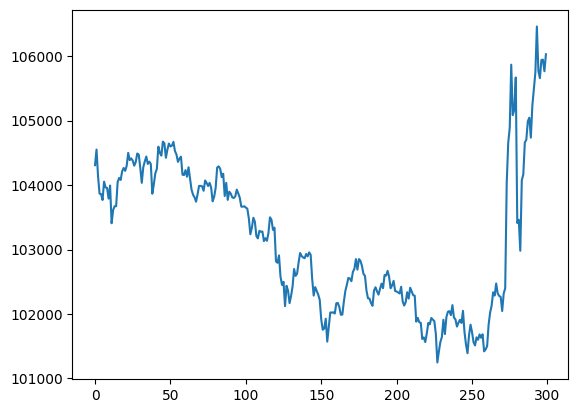

In [8]:
df_candles['fechamento'].plot()
df_candles

In [20]:


def posicao_max(symbol, max_pos):
   pos = posicoes_abertas(symbol)[1]
   if isinstance(pos, list):
        max_posicao = False
   elif float(pos) >= max_pos:
        max_posicao = True 
   else:
        max_posicao = False

   return max_posicao    


False


In [ ]:
def ultima_orderm_aberta():
    order = []
    order = binance.fetch_orders(symbol)[-1]['status']
    if order == 'open':
        open_order = True
    else:
        open_oder = False
    return open_order        

ultima_orderm_aberta('XRPSUDT')